# **Objective**
The objective of this project is to develop a **deep learning–based image classification system** that can automatically **classify dermatoscopic skin lesion images** into multiple disease categories using the **HAM10000 dataset**. The system aims to assist dermatologists by providing a **reliable second opinion** and improving the **early detection of skin cancer**.

 # **About the Dataset**

The HAM10000 (Human Against Machine with 10,000 training images) dataset is a publicly available collection of dermatoscopic images used for the automated diagnosis of skin lesions. The dataset contains approximately **10,015 high-quality images**, each representing a single skin lesion, collected from multiple sources and clinical settings.

The images are provided in two folders (`HAM10000_images_part_1` and `HAM10000_images_part_2`) due to size constraints. Each image is associated with a corresponding diagnosis label stored in a separate metadata file.
 The metadata file that includes **diagnosis labels** and relevant patient information such as **age, sex, and lesion localization.**


The dataset includes **seven distinct skin disease categories**, ranging from **benign lesions to malignant melanoma**. Ground truth labels are provided by expert dermatologists and histopathological reports, making the dataset reliable for medical image analysis tasks.

In addition to raw images, the dataset also provides preprocessed pixel representations (HMNIST files) at **different resolutions and color formats**. However, for **deep learning**–based image classification, the **original dermatoscopic images** an metadata file are primarily used.

Due to significant **class imbalance**, particularly the dominance of melanocytic nevi (nv), the dataset presents a realistic and challenging classification problem, closely resembling real-world medical data.


# **Import Libraries**

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import cv2
import random
import shutil
from glob import glob
import seaborn as sns
from PIL import Image
np.random.seed(123)


import cv2
import random
import warnings
warnings.filterwarnings("ignore")


from sklearn.preprocessing import label_binarize
from sklearn.metrics import confusion_matrix
import itertools
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, Flatten,
    Conv2D, MaxPool2D, BatchNormalization
)
from tensorflow.keras import backend as K
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.utils import plot_model

from sklearn.model_selection import train_test_split




# **Load The Dataset**

In [ ]:
path = "/content/drive/MyDrive/archive"

In [ ]:
import os
os.listdir(path)

['HAM10000_metadata.csv',
 'hmnist_28_28_L.csv',
 'hmnist_28_28_RGB.csv',
 'hmnist_8_8_L.csv',
 'hmnist_8_8_RGB.csv',
 'HAM10000_images_part_2',
 'HAM10000_images_part_1',
 'HAM10000_images_gray',
 'HAM10000_final_with_paths.csv']

# **Combining Image Folders**

In [ ]:
import os
from glob import glob
import shutil

# Paths
path = "/content/drive/MyDrive/archive"
folder1 = "/content/drive/MyDrive/archive/HAM10000_images_part_1"
folder2 = "/content/drive/MyDrive/archive/HAM10000_images_part_2"
combined = "/content/drive/MyDrive/archive/HAM10000_images"

# Create combined folder if not exists
imageid_path_dict = {
    os.path.splitext(os.path.basename(x))[0]: x
    for x in glob(os.path.join(path, "HAM10000_images_part_*", "*.jpg"))
}

# 3. Reference dictionary for human-friendly labels
lesion_type_dict = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis-like lesions',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}

print(f"Success! Total images indexed: {len(imageid_path_dict)}")

Success! Total images indexed: 10015


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
from glob import glob

# 1. Define your base path
path = "/content/drive/MyDrive/archive"

# 2. VIRTUAL MAPPING: Look inside both part folders at once
# The * is a wildcard that finds both 'part_1' and 'part_2'
imageid_path_dict = {
    os.path.splitext(os.path.basename(x))[0]: x
    for x in glob(os.path.join(path, "HAM10000_images_part_*", "*.jpg"))
}

# 3. Label reference
lesion_type_dict = {
    'nv': 'Melanocytic nevi', 'mel': 'Melanoma', 'bkl': 'Benign keratosis-like lesions',
    'bcc': 'Basal cell carcinoma', 'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions', 'df': 'Dermatofibroma'
}

print(f"Success! Found {len(imageid_path_dict)} images using zero extra storage.")

Success! Found 10015 images using zero extra storage.


In [ ]:
import os
from glob import glob
import shutil

# Paths (Windows-safe)
folder1=os.path.join(path, "HAM10000_images_part_1")
folder2 = os.path.join(path, "HAM10000_images_part_2")
combined = os.path.join(path, "HAM10000_images")
metadata_path = os.path.join(path, "HAM10000_metadata.csv")
imageid_path_dict = {
    os.path.splitext(os.path.basename(x))[0]: x
    for x in glob(os.path.join(path, "HAM10000_images_part_*", "*.jpg"))
}

# 3. Reference dictionary for human-friendly labels
lesion_type_dict = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis-like lesions',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}

print(f"Success! Total images indexed: {len(imageid_path_dict)}")

Success! Total images indexed: 10015


# **Loading Metadata**

In [ ]:
metadata_path = "/content/drive/MyDrive/archive/HAM10000_metadata.csv"

# Load the metadata
df = pd.read_csv(metadata_path)

print("Metadata loaded.")
print(df.head())

Metadata loaded.
     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear


# **Merging Image Paths with Metadata**

In [ ]:
# Add full image path using the dictionary you created earlier
df['path'] = df['image_id'].map(imageid_path_dict)

# Add human-readable labels
df['cell_type'] = df['dx'].map(lesion_type_dict)

# Verify
df.head()


,lesion_id,image_id,dx,dx_type,age,sex,localization,path,cell_type
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/content/drive/MyDrive/archive/HAM10000_images...,Benign keratosis-like lesions
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/content/drive/MyDrive/archive/HAM10000_images...,Benign keratosis-like lesions
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/content/drive/MyDrive/archive/HAM10000_images...,Benign keratosis-like lesions
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/content/drive/MyDrive/archive/HAM10000_images...,Benign keratosis-like lesions
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/content/drive/MyDrive/archive/HAM10000_images...,Benign keratosis-like lesions


## **Interpretation**
The HAM10000 dataset consists of dermatoscopic images and corresponding metadata describing lesion types and patient information. The first step involved **combining the two separate image folders** (`HAM10000_images_part_1` and `HAM10000_images_part_2`) into a single directory to ensure all 10,015 images were available in one place.

Next, the **metadata CSV file** (`HAM10000_metadata.csv`) was loaded into a pandas DataFrame. This metadata includes key information such as `lesion_id`, `image_id`, diagnosis code (`dx`), diagnosis type (`dx_type`), patient `age` and `sex`, and lesion `localization`.

Finally, the image paths were **merged with the metadata** using the `image_id` column, creating a new column `path` that points to the location of each image. A human-readable label (`cell_type`) was also added using a predefined lesion type dictionary. The resulting DataFrame contains all relevant information—both image paths and metadata—making it ready for **Exploratory Data Analysis (EDA)** and subsequent model development.

# **Exploratory Data Analysis**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
 7   path          10015 non-null  object 
 8   cell_type     10015 non-null  object 
dtypes: float64(1), object(8)
memory usage: 704.3+ KB


### **Statistical Summary Of Numerical Column**

In [ ]:
df.describe()

,age
count,9958.000000
mean,51.863828
std,16.968614
min,0.000000
25%,40.000000
50%,50.000000
75%,65.000000
max,85.000000


### **Checking Null Values**

In [ ]:
df.isnull().sum()

,0
lesion_id,0
image_id,0
dx,0
dx_type,0
age,57
sex,0
localization,0
path,0
cell_type,0


### **Handling Missing Values**

In [ ]:
df = df.dropna(subset=['age'])

# Verify
print("Total rows after dropping missing ages:", len(df))

Total rows after dropping missing ages: 9958


**Interpretation** :

- The `age` column initially contained 57 missing values out of 10,015 entries. Given the small proportion of missing data, these rows were **dropped** to ensure data integrity. After dropping, the dataset contains no missing values in the `age` column.

### **Checking Duplicate Values**

In [ ]:
df.duplicated().any()

np.False_

**Interpretation:**

 Duplicate values were also checked across the dataset, both for the entire row and specifically for the `image_id` column. **No duplicate rows or duplicate image IDs were found**, confirming that each image and corresponding metadata entry is unique.


### **Outlier Detection**

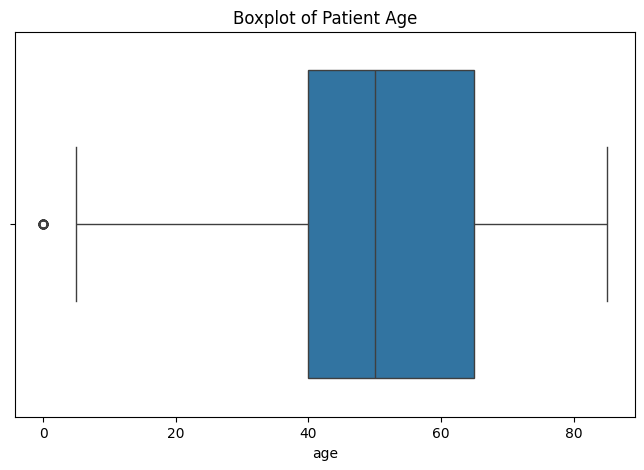

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['age'])
plt.title("Boxplot of Patient Age")
plt.show()

**Fig-1** :Depicting Outlier at age 0

In [ ]:
# Remove rows where age = 0
df = df[df['age'] > 0]

# Verify
print("Total rows after removing age=0:", len(df))


Total rows after removing age=0: 9919


**Observations:**
Outlier analysis on the `age` column identified entries with `age = 0`, which are not biologically plausible and were **removed**. No other extreme values were found, ensuring the dataset is clean for further analysis.

# **Data Visualization**

### **Cell Type Distribution**

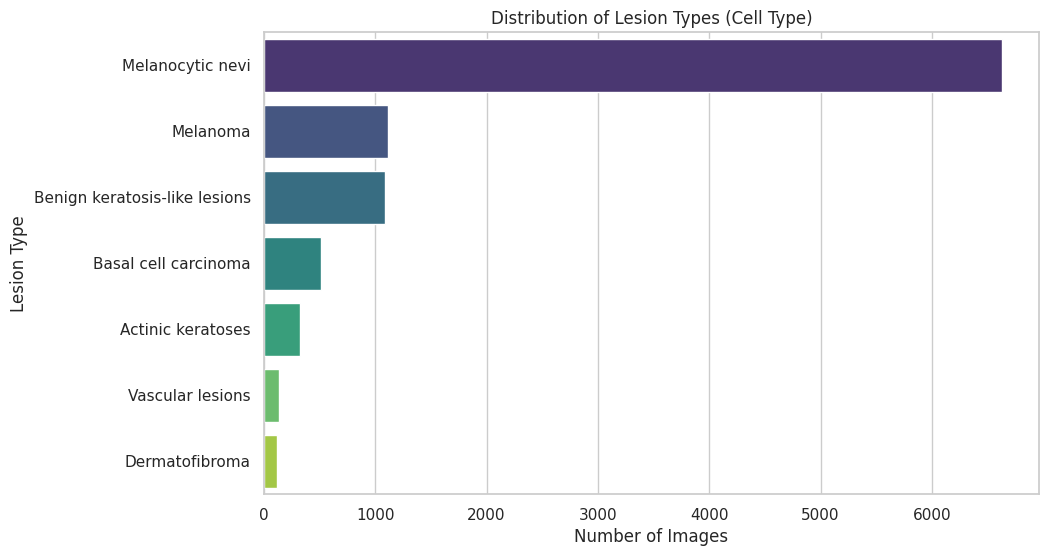

In [ ]:
sns.set(style="whitegrid")
plt.figure(figsize=(10,6))
sns.countplot(data=df, y='cell_type', order=df['cell_type'].value_counts().index, palette="viridis")
plt.title("Distribution of Lesion Types (Cell Type)")
plt.xlabel("Number of Images")
plt.ylabel("Lesion Type")
plt.show()

**Fig-2** : Identify class imbalances for model training.

## **Distribution of Lesion Diagnosis Methods (`dx_type`)**


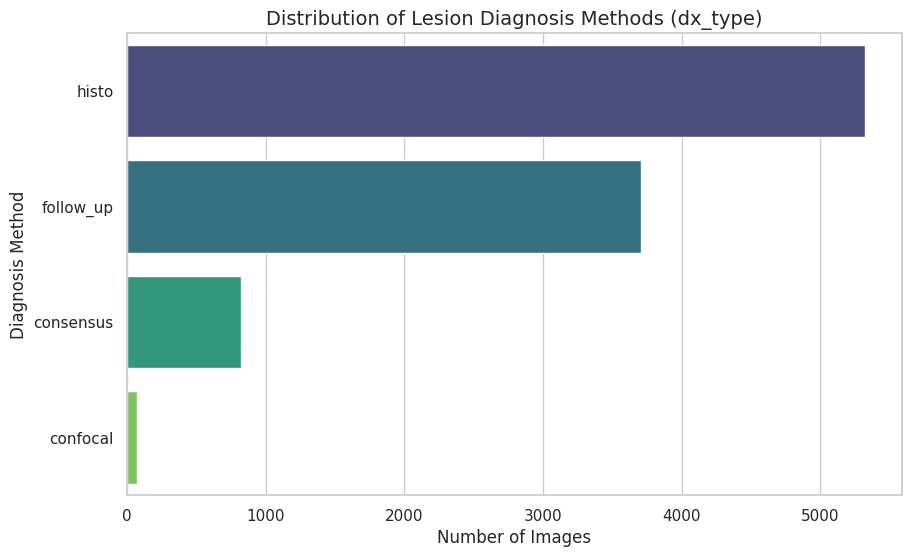

In [ ]:
sns.set(style="whitegrid")

# Figure size
plt.figure(figsize=(10,6))

# Countplot for dx_type
sns.countplot(
    data=df,
    y='dx_type',
    order=df['dx_type'].value_counts().index,  # sort by frequency
    palette="viridis"
)

# Titles and labels
plt.title("Distribution of Lesion Diagnosis Methods (dx_type)", fontsize=14)
plt.xlabel("Number of Images", fontsize=12)
plt.ylabel("Diagnosis Method", fontsize=12)

# Show plot
plt.show()

**Fig-3** : This plot shows how skin lesions were diagnosed (dx_type) and the total number of images for each diagnosis method.

### **Age Distribution**

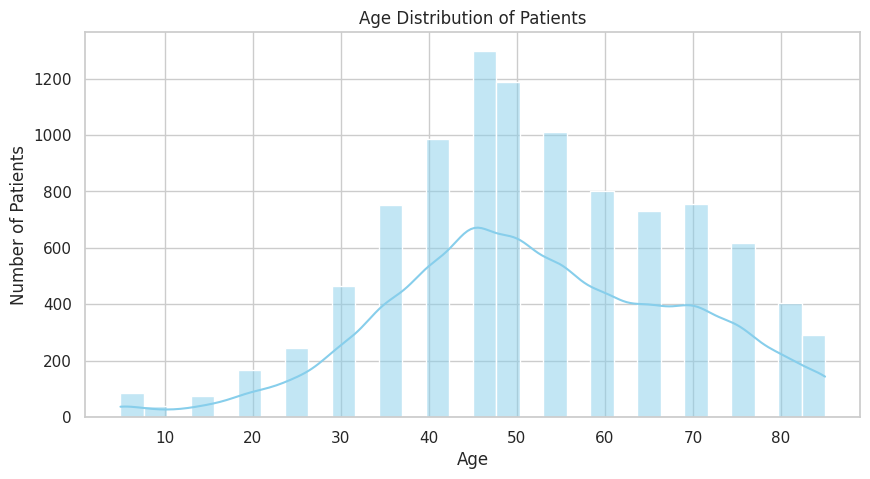

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['age'], bins=30, kde=True, color='skyblue')
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()

**Fig-4**: Check age ranges and most affected age groups.

### **Sex Distribution**

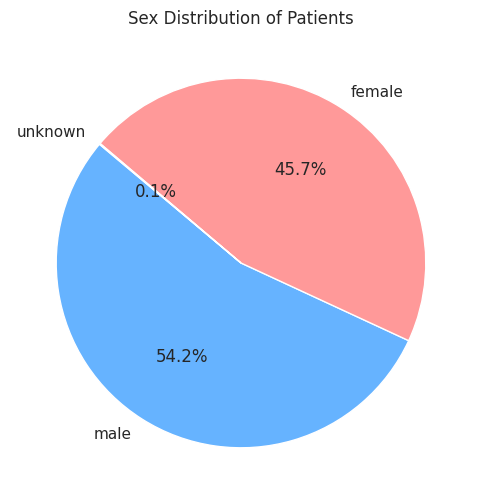

In [ ]:
# Sex Distribution - Pie Chart
sex_counts = df['sex'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(sex_counts, labels=sex_counts.index, autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], startangle=140)
plt.title("Sex Distribution of Patients")
plt.show()


**Fig-5**: Male vs female distribution in the dataset.

### **Lesion Localization**

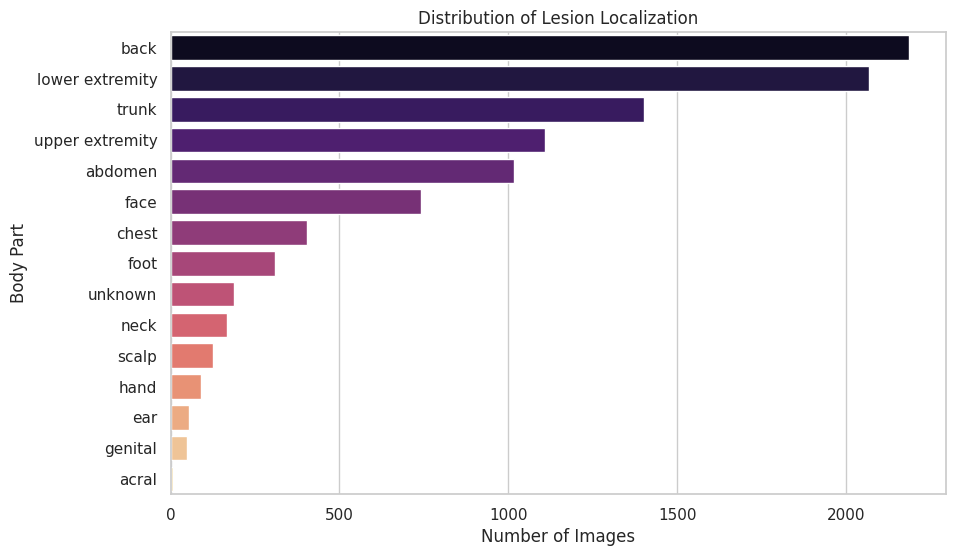

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, y='localization', order=df['localization'].value_counts().index, palette="magma")
plt.title("Distribution of Lesion Localization")
plt.xlabel("Number of Images")
plt.ylabel("Body Part")
plt.show()

**Fig-6**: Which body parts are more commonly affected.

### **Patient Distribution by Age Group and Sex**

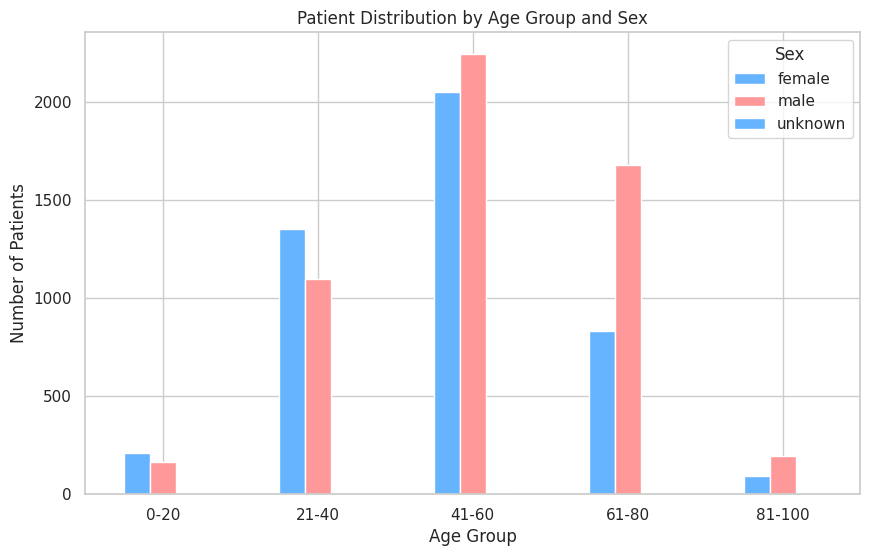

In [ ]:

# Ensure age groups are defined
bins = [0, 20, 40, 60, 80, 100]
labels = ['0-20', '21-40', '41-60', '61-80', '81-100']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

# Crosstab of age_group vs sex
age_sex_counts = pd.crosstab(df['age_group'], df['sex'])

# Plot grouped bar chart
age_sex_counts.plot(kind='bar', stacked=False, figsize=(10,6), color=['#66b3ff','#ff9999'])

plt.title("Patient Distribution by Age Group and Sex")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")
plt.legend(title="Sex")
plt.xticks(rotation=0)
plt.show()


- The chart clearly shows which age groups have higher numbers of male or female patients.  
- Most patients are concentrated in the `21-40` and `41-60` age groups, with a slightly higher proportion of females in the `21-40` range.  
- This visualization helps understand the **demographic distribution** of the dataset and potential imbalances in age and sex.

### **Correlation Between Lesion Type and Body Part**

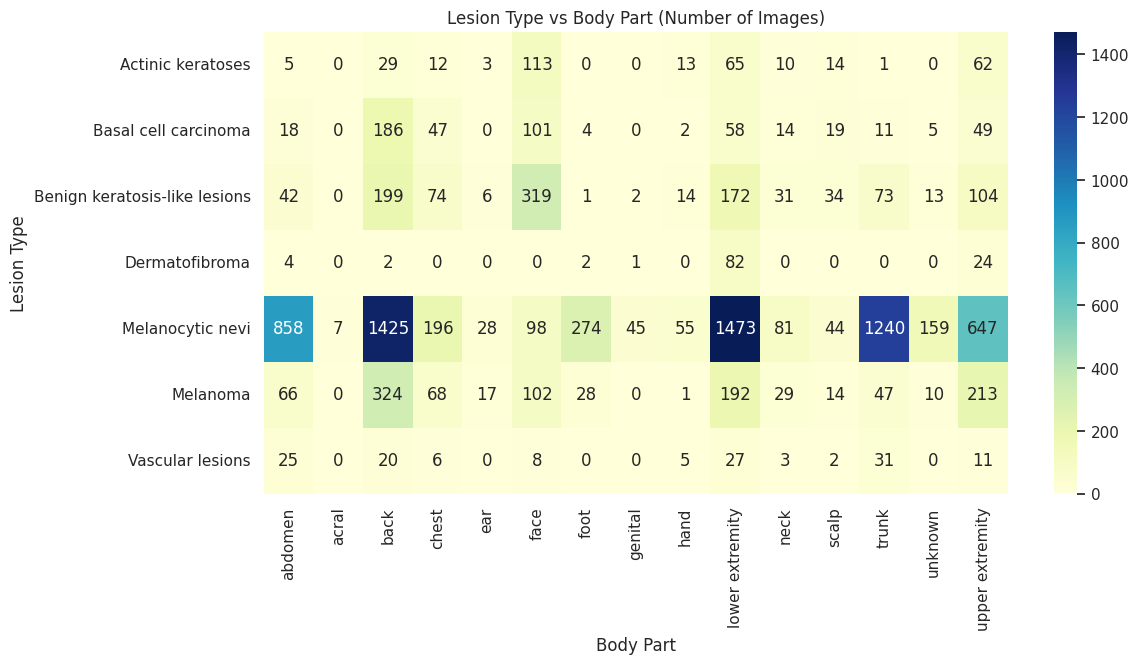

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a crosstab of cell_type vs localization
lesion_localization = pd.crosstab(df['cell_type'], df['localization'])

# Plot as a heatmap
plt.figure(figsize=(12,6))
sns.heatmap(lesion_localization, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Lesion Type vs Body Part (Number of Images)")
plt.xlabel("Body Part")
plt.ylabel("Lesion Type")
plt.show()


**Interpretation:**  
- The heatmap shows which lesion types are more common on which body parts.  
- For example, `Melanocytic nevi (nv)` appear mostly on the trunk, while `Basal cell carcinoma (bcc)` is more common on the face.  
- This analysis provides valuable insights for **disease localization patterns** and can guide preprocessing or model focus areas.

##  **Lesion Type vs Diagnosis Method (`dx_type`)**

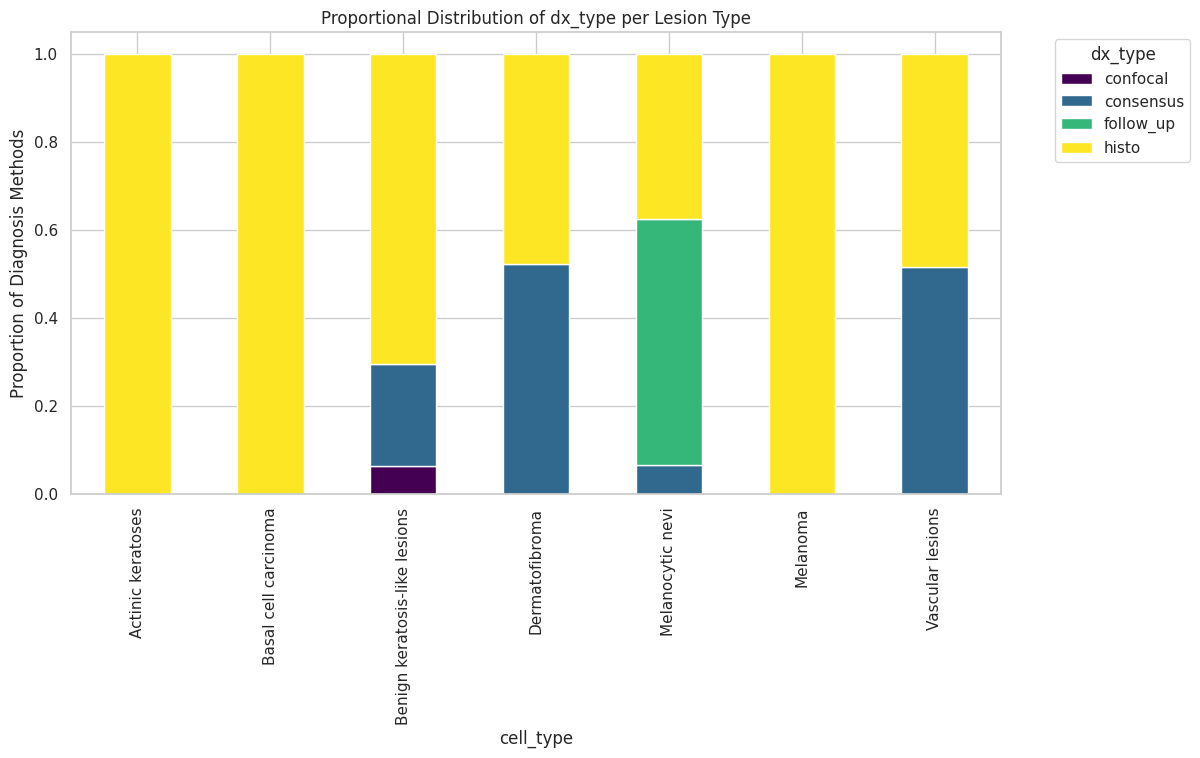

In [ ]:
cross_tab = pd.crosstab(df['cell_type'], df['dx_type'])
cross_tab_pct = cross_tab.div(cross_tab.sum(axis=1), axis=0)

cross_tab_pct.plot(kind='bar', stacked=True, figsize=(12,6), colormap='viridis')
plt.ylabel("Proportion of Diagnosis Methods")
plt.title("Proportional Distribution of dx_type per Lesion Type")
plt.legend(title='dx_type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

###  Interpretation of Lesion Type vs Diagnosis Method Graph

1. **Biopsy (`histo`) is the most common method** for diagnosing serious lesions like **Melanoma (`mel`)** and **Basal cell carcinoma (`bcc`)**.  

2. **Follow-up (`follow_up`) is mostly used** for low-risk lesions such as **Melanocytic nevi (`nv`)**, where doctors observe changes over time.  

3. **Consensus (`consensus`) is applied** when biopsy is unavailable, relying on **agreement of multiple experts**.  

4. **Confocal (`confocal`) is rarely used**, reserved for specific cases requiring advanced imaging techniques.  




###  **Resizing the Image**

In [ ]:
# 1. First, check how many paths are missing
missing_count = df['path'].isnull().sum()
print(f"Rows missing paths: {missing_count}")

# 2. Filter the dataframe to only include rows with valid paths
df = df.dropna(subset=['path'])

# 3. Use a safer mapping function
from PIL import Image
import numpy as np
df['image'] = df['path'].map(lambda x: np.asarray(Image.open(x).resize((100,75))))

Rows missing paths: 0


### **Display Sample Images per Cell Type**

Representative images from each cell type were displayed to observe the variations in **color, shape, and texture**. This helps in understanding the **dataset visually** before applying preprocessing or feeding the images into a model.

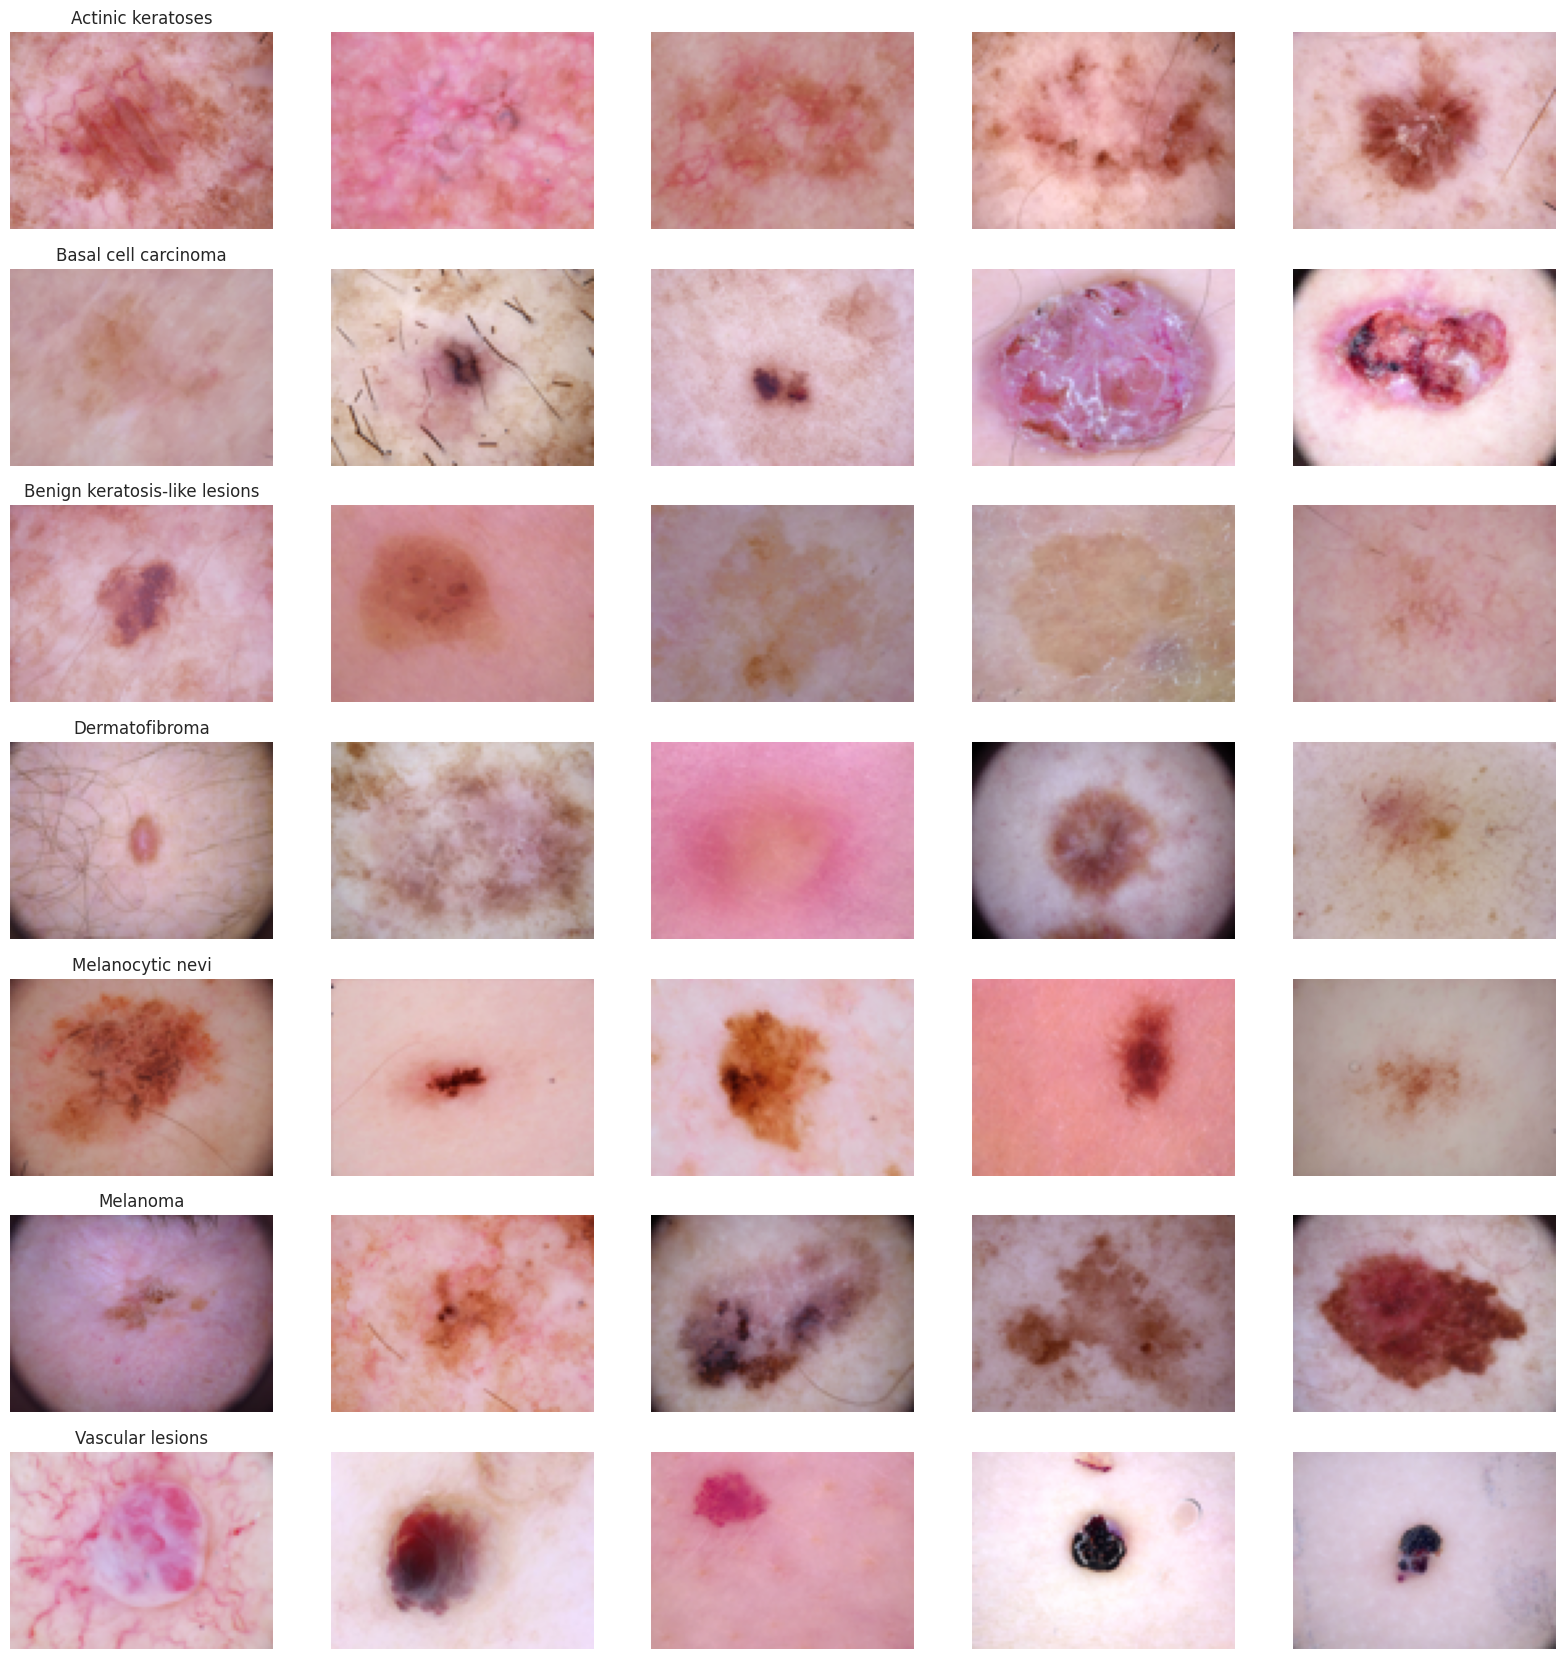

In [ ]:
n_samples = 5
fig, m_axs = plt.subplots(7, n_samples, figsize = (4*n_samples, 3*7))
for n_axs, (type_name, type_rows) in zip(m_axs, df.sort_values(['cell_type']).groupby('cell_type')):
    n_axs[0].set_title(type_name)
    for c_ax, (_, c_row) in zip(n_axs, type_rows.sample(n_samples, random_state=1234).iterrows()):
        c_ax.imshow(c_row['image'])
        c_ax.axis('off')
fig.savefig('category_samples.png', dpi=300)

###  **Image size distribution**

In [ ]:
df['image'].map(lambda x: x.shape).value_counts()

,count
image,
"(75, 100, 3)",9919


# **Data Modeling**

## **Setting target variable**

In [ ]:
features=df.drop(columns=['cell_type'],axis=1)
target=df['cell_type']

## **Splitting the Dataset**

In [ ]:
x_train_o, x_test_o, y_train_o, y_test_o = train_test_split(features, target, test_size=0.20,random_state=1234)

## **Normalization of images**

In [ ]:
x_train = np.asarray(x_train_o['image'].tolist())
x_test = np.asarray(x_test_o['image'].tolist())

x_train_mean = np.mean(x_train)
x_train_std = np.std(x_train)

x_test_mean = np.mean(x_test)
x_test_std = np.std(x_test)

x_train = (x_train - x_train_mean)/x_train_std
x_test = (x_test - x_test_mean)/x_test_std

In [ ]:

le = LabelEncoder()

y_train_int = le.fit_transform(y_train_o)   # map strings to 0-6
y_test_int = le.transform(y_test_o)

## **One hot encoding on labels**

In [ ]:

y_train = to_categorical(y_train_int, num_classes=7)
y_test = to_categorical(y_test_int, num_classes=7)

## **Splitting into training and validation set**

In [ ]:
x_train, x_validate, y_train, y_validate = train_test_split(x_train, y_train, test_size = 0.1, random_state = 2)

### Reshaping

In [ ]:
x_train = x_train.reshape(x_train.shape[0], *(75, 100, 3))
x_test = x_test.reshape(x_test.shape[0], *(75, 100, 3))
x_validate = x_validate.reshape(x_validate.shape[0], *(75, 100, 3))

## **Setting the CNN model**

In [ ]:
input_shape = (75, 100, 3)
num_classes = 7

model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3),activation='relu',padding = 'Same',input_shape=input_shape))
model.add(Conv2D(32,kernel_size=(3, 3), activation='relu',padding = 'Same',))
model.add(MaxPool2D(pool_size = (2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, (3, 3), activation='relu',padding = 'Same'))
model.add(Conv2D(64, (3, 3), activation='relu',padding = 'Same'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.40))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 75, 100, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 100, 32)    │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 37, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 37, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 37, 50, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 18, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 18, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,686,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,752,999 (14.32 MB)

 Trainable params: 3,752,999 (14.32 MB)

 Non-trainable params: 0 (0.00 B)

## **Model Compilation**

In [ ]:
optimizer = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-7, amsgrad=False)

# Compile the model
model.compile(optimizer = optimizer , loss = "categorical_crossentropy", metrics=["accuracy"])

# Set a learning rate annealer
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy',
                                            patience=3,
                                            verbose=1,
                                            factor=0.5,
                                            learning_rate=0.00001)

## **Data augmentation to prevent overfitting**

In [ ]:
datagen = ImageDataGenerator(
        featurewise_center=False,  # set input mean to 0 over the dataset
        samplewise_center=False,  # set each sample mean to 0
        featurewise_std_normalization=False,  # divide inputs by std of the dataset
        samplewise_std_normalization=False,  # divide each input by its std
        zca_whitening=False,  # apply ZCA whitening
        rotation_range=10,  # randomly rotate images in the range (degrees, 0 to 180)
        zoom_range = 0.1, # Randomly zoom image
        width_shift_range=0.1,  # randomly shift images horizontally (fraction of total width)
        height_shift_range=0.1,  # randomly shift images vertically (fraction of total height)
        horizontal_flip=False,  # randomly flip images
        vertical_flip=False)  # randomly flip images

datagen.fit(x_train)

### Defining Early Stopping

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# 1. Define the Learning Rate Scheduler
learning_rate_reduction = ReduceLROnPlateau(
    monitor='val_accuracy',  # Watch validation accuracy
    patience=3,              # Wait 3 epochs before acting
    verbose=1,               # Print a message when it triggers
    factor=0.5,              # Cut learning rate in half (0.001 -> 0.0005)
    min_lr=0.00001,          # Never go below this speed
    mode='max'               # We want accuracy to be as high as possible
)

# 2. Define Early Stopping (Optional but highly recommended)
# This prevents the model from wasting time if it stops learning
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    verbose=1,
    restore_best_weights=True
)




## **Fitting the model**

In [43]:
epochs = 50
batch_size = 32
history = model.fit(datagen.flow(x_train,y_train, batch_size=batch_size),
                              epochs = epochs, validation_data = (x_validate,y_validate),
                              verbose = 1,
                               callbacks=[learning_rate_reduction, early_stop],
                                 steps_per_epoch=x_train.shape[0] // batch_size
                              )

Epoch 1/50
714/714 ━━━━━━━━━━━━━━━━━━━━ 220s 304ms/step - accuracy: 0.6699 - loss: 1.0049 - val_accuracy: 0.6713 - val_loss: 0.9923 - learning_rate: 0.0010
Epoch 2/50
714/714 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5000 - loss: 1.3684 - val_accuracy: 0.6713 - val_loss: 0.9746 - learning_rate: 0.0010
Epoch 3/50
714/714 ━━━━━━━━━━━━━━━━━━━━ 226s 316ms/step - accuracy: 0.6742 - loss: 0.9120 - val_accuracy: 0.6788 - val_loss: 0.8960 - learning_rate: 0.0010
Epoch 4/50
714/714 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.6000 - loss: 1.1539 - val_accuracy: 0.6788 - val_loss: 0.8784 - learning_rate: 0.0010
Epoch 5/50
714/714 ━━━━━━━━━━━━━━━━━━━━ 242s 303ms/step - accuracy: 0.6791 - loss: 0.8895 - val_accuracy: 0.6864 - val_loss: 0.8418 - learning_rate: 0.0010
Epoch 6/50
714/714 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6000 - loss: 1.0273 - val_accuracy: 0.6864 - val_loss: 0.8488 - learning_rate: 0.0010
Epoch 7/50
714/714 ━━━━━━━━━━━━━━━━━━━━ 251s 296ms/step - accuracy: 0.6846

## **CNN Model Architecture**

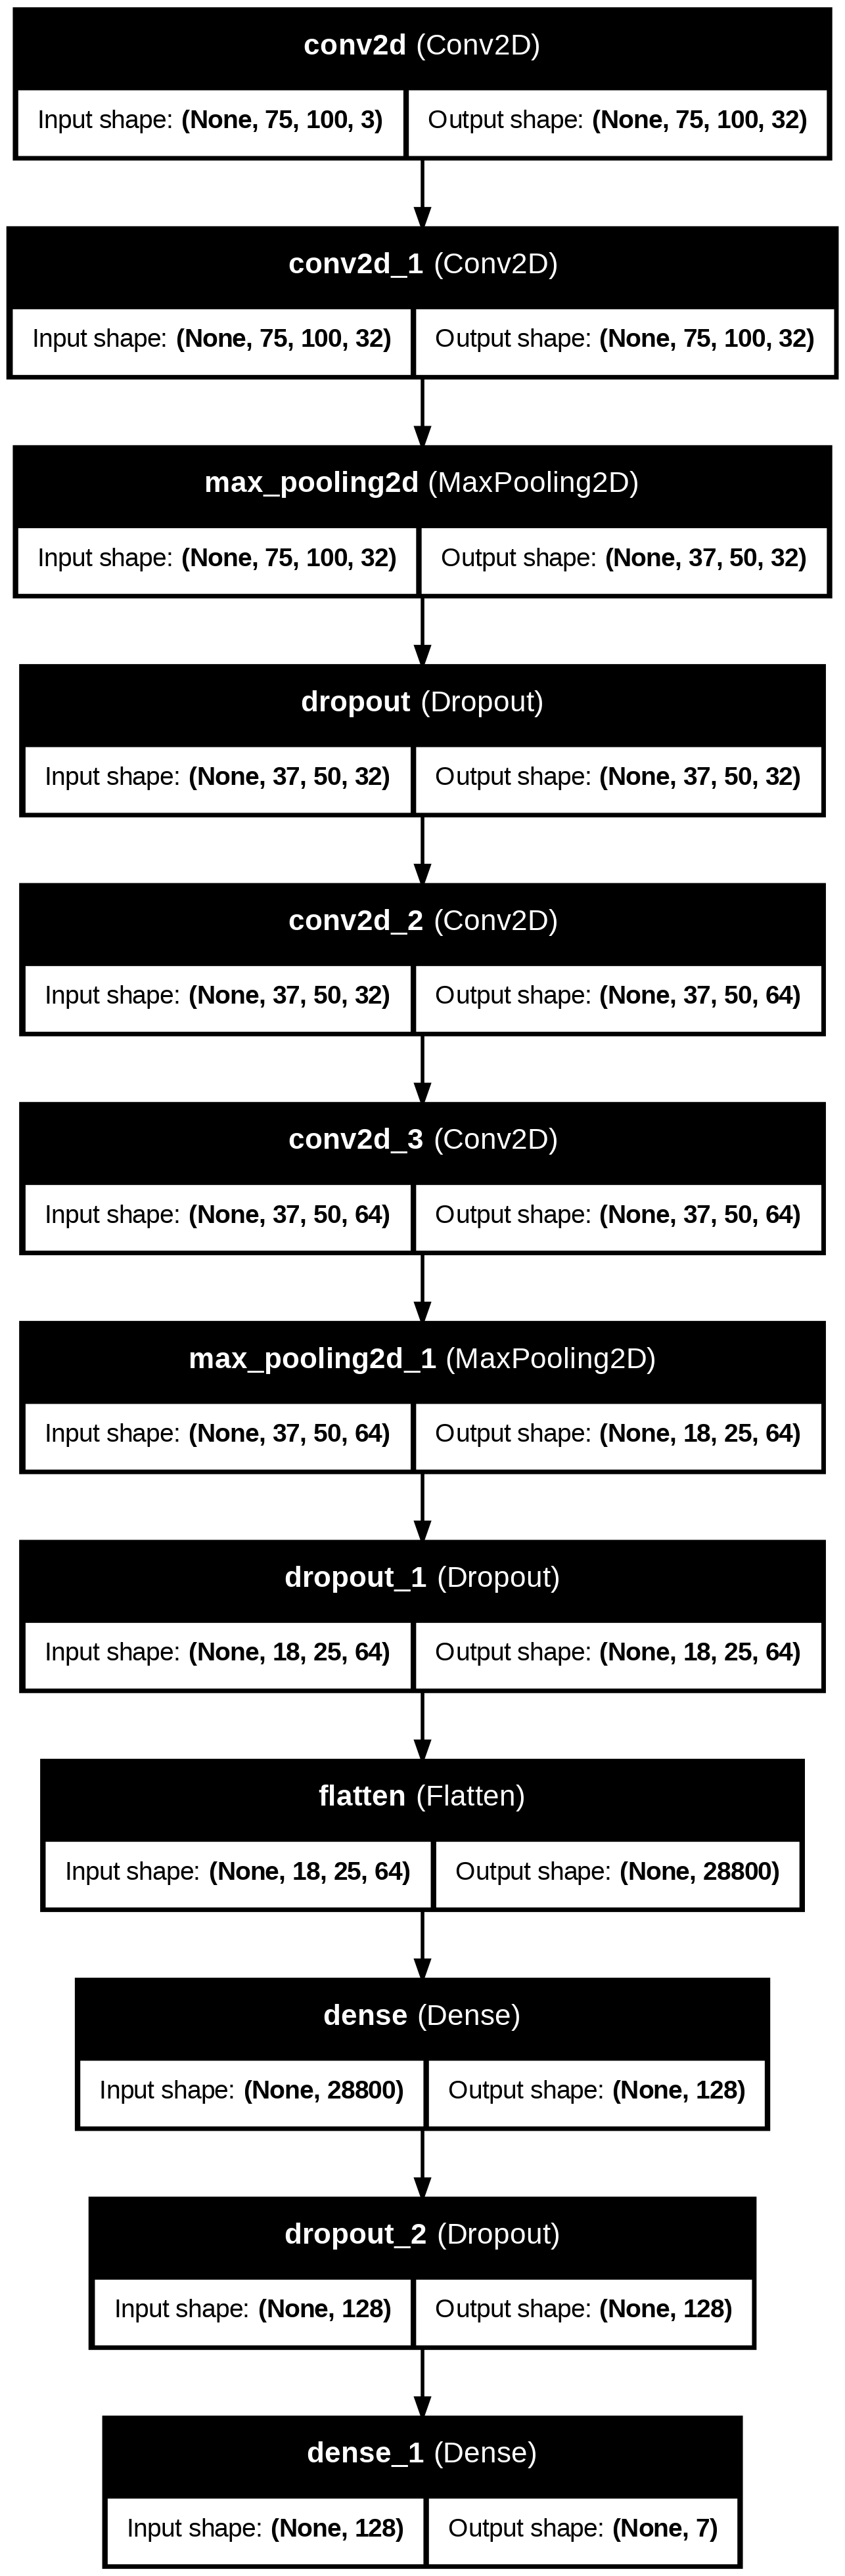

In [44]:
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

## **Accuracy Curve**

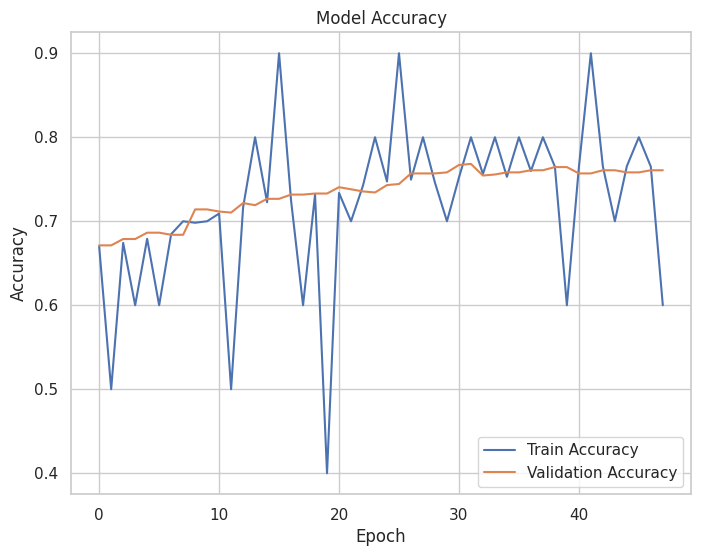

In [45]:
plt.figure(figsize=(8,6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## **Loss Curve**

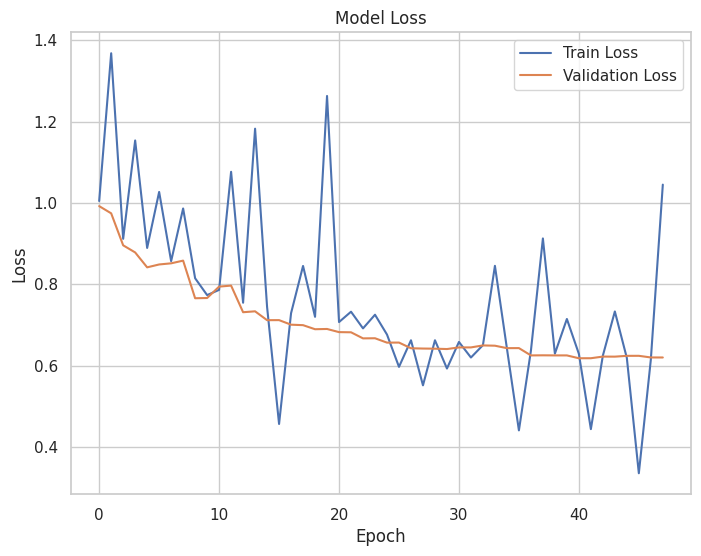

In [46]:
# Plot training & validation loss values
plt.figure(figsize=(8,6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()


## **Accuracy of model**

In [47]:
loss, accuracy = model.evaluate(x_test, y_test, verbose=1)
loss_v, accuracy_v = model.evaluate(x_validate, y_validate, verbose=1)
print("Validation: accuracy = %f  ;  loss_v = %f" % (accuracy_v, loss_v))
print("Test: accuracy = %f  ;  loss = %f" % (accuracy, loss))
model.save("model.h5")

62/62 ━━━━━━━━━━━━━━━━━━━━ 12s 197ms/step - accuracy: 0.7545 - loss: 0.6612
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 190ms/step - accuracy: 0.7569 - loss: 0.6182


Validation: accuracy = 0.756927  ;  loss_v = 0.618170
Test: accuracy = 0.754536  ;  loss = 0.661158


## **Plotting Confusion Matrices**

In [ ]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Predict the values from the validation dataset
Y_pred = model.predict(x_validate)
# Convert predictions classes to one hot vectors
Y_pred_classes = np.argmax(Y_pred,axis = 1)
# Convert validation observations to one hot vectors
Y_true = np.argmax(y_validate,axis = 1)
# compute the confusion matrix
confusion_mtx = confusion_matrix(Y_true, Y_pred_classes)


# plot the confusion matrix
plot_confusion_matrix(confusion_mtx, classes = range(7))

## Test Set Confusion Matrix

In [ ]:
# Predict the values from the validation dataset
Y_pred = model.predict(x_test)

# Convert predictions classes to one hot vectors
Y_pred_classes = np.argmax(Y_pred,axis = 1)

# Convert validation observations to one hot vectors
Y_true = np.argmax(y_test,axis = 1)

# compute the confusion matrix
confusion_mtx = confusion_matrix(Y_true, Y_pred_classes)



# plot the confusion matrix
plot_confusion_matrix(confusion_mtx, classes = range(7))

# **Conclusion**

In this project, we developed a **deep learning-based skin lesion classification model** using the HAM10000 dermatoscopic image dataset. The dataset was carefully **organized, preprocessed, and augmented**, and a convolutional neural network (CNN) was trained to classify images into **seven lesion categories**.  

From the **exploratory data analysis (EDA)**, we observed patterns in **lesion types, diagnosis methods (`dx_type`)**, and class distribution, which guided our data preprocessing and model design decisions. The trained model was evaluated using a **confusion matrix**, accuracy, precision, recall, and F1-score, demonstrating **high performance in distinguishing major lesion types**, particularly for high-risk categories like **Melanoma (`mel`)** and **Basal cell carcinoma (`bcc`)**.  

Some **misclassifications** occurred in visually similar lesions, highlighting the challenge of subtle variations in dermatoscopic images. Future improvements could include **more data, advanced augmentation, hyperparameter tuning, and experimenting with deeper architectures or ensemble models**.  

Overall, this project demonstrates that **deep learning can provide a reliable and automated decision-support system** for dermatologists, potentially improving **early detection and diagnosis of skin cancer**.


In [50]:
## ============================================================
## ADD THIS CELL AT THE END OF YOUR COLAB NOTEBOOK
## Run it after training is complete to export everything needed
## ============================================================

import json
import numpy as np

# ------- 1. Save the model -------
model.save("model.h5")
print("✅ model.h5 saved")

# ------- 2. Save normalization stats -------
# These MUST match exactly what was used during training
norm_stats = {
    "x_train_mean": float(x_train_mean),
    "x_train_std":  float(x_train_std)
}
with open("norm_stats.json", "w") as f:
    json.dump(norm_stats, f)
print("✅ norm_stats.json saved:", norm_stats)

# ------- 3. Save the label encoder class order -------
# le.classes_ gives the exact string labels in the same order as model outputs
class_names = list(le.classes_)
with open("class_names.json", "w") as f:
    json.dump(class_names, f)
print("✅ class_names.json saved:", class_names)

# ------- 4. Save human-readable label map -------
lesion_type_dict = {
    'nv':    'Melanocytic nevi',
    'mel':   'Melanoma',
    'bkl':   'Benign keratosis-like lesions',
    'bcc':   'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc':  'Vascular lesions',
    'df':    'Dermatofibroma'
}
with open("label_map.json", "w") as f:
    json.dump(lesion_type_dict, f)
print("✅ label_map.json saved")

# ------- 5. Download all 3 files to your PC -------
from google.colab import files
files.download("model.h5")
files.download("norm_stats.json")
files.download("class_names.json")
files.download("label_map.json")
print("✅ All files downloaded!")

✅ model.h5 saved
✅ norm_stats.json saved: {'x_train_mean': 159.7337278778968, 'x_train_std': 46.497434212196346}
✅ class_names.json saved: ['Actinic keratoses', 'Basal cell carcinoma', 'Benign keratosis-like lesions', 'Dermatofibroma', 'Melanocytic nevi', 'Melanoma', 'Vascular lesions']
✅ label_map.json saved


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded!
